# Recursive Forecast Evaluation

Following Scarrott (LectureSet13), we evaluate each model with a **recursive multi-step forecast** on a 20-week hold-out.

**LectureSet13** — for a zero-mean AR(1) process $X_t = \phi X_{t-1} + W_t$, the $m$-step forecast is:

$$\tilde{X}_{n+m|n} = \phi\,\tilde{X}_{n+m-1|n} = \phi^m X_n$$

Each forecast feeds into the next; as $m$ grows the prediction reverts to the mean.

**Our adaptation** — each model has a time-varying mean $\mu_t$, so the AR(1) acts on deviations:

$$y_t = \mu_t + \phi(y_{t-1} - \mu_{t-1}) + W_t$$

The recursive forecast becomes:

$$\tilde{y}_{n+m|n} = \mu_{n+m} + \phi\bigl(\tilde{y}_{n+m-1|n} - \mu_{n+m-1}\bigr)$$

where $\tilde{y}_{n|n} = y_n$ (the last training observation). After step 1, every prediction depends on the **previous forecast**, not the true value.

We score with **MSE** $= \frac{1}{H}\sum_{m=1}^{H}(y_{n+m} - \tilde{y}_{n+m|n})^2$ over $H = 20$ hold-out weeks across all 6 regions.

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'models').exists() and (candidate / 'exploratory' / 'bayes_models').exists():
            return candidate
    raise RuntimeError('Could not locate repo root')


ROOT = find_repo_root()
DATA = ROOT / 'data'
MODELS = DATA / 'models'
RAW = DATA / 'raw data'
OUTPUT_DIR = MODELS / 'holdout_region_eval'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHORT_NAMES = {
    'HSE Dublin and Midlands': 'Dublin & Midlands',
    'HSE Dublin and North East': 'Dublin & NE',
    'HSE Dublin and South East': 'Dublin & SE',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & NW',
}

HOLDOUT_FILE = RAW / 'weekly_by_region_202604082051.csv'

SELECTED_MODELS = {
    'v1': {'label': 'V1 AR(1)+Annual Cycle', 'native_scale': 'per10k', 'delta_mode': 'none'},
    'v2': {'label': 'V2 Event Effects',      'native_scale': 'per10k', 'delta_mode': 'global'},
    'v3': {'label': 'V3 Regional New Year',   'native_scale': 'per10k', 'delta_mode': 'region'},
    'v4': {'label': 'V4 Partial Pooling',     'native_scale': 'per10k', 'delta_mode': 'region'},
    'v5': {'label': 'V5 Cost Baseline',       'native_scale': 'per10k', 'delta_mode': 'region'},
    'v6': {'label': 'V6 Hosp Density',        'native_scale': 'per10k', 'delta_mode': 'region'},
    'v7': {'label': 'V7 Budget Scaled',       'native_scale': 'budget', 'delta_mode': 'region'},
}

In [31]:
# ── Load training and hold-out data ──

def load_wide_matrix(csv_path, regions):
    df = pd.read_csv(csv_path)
    df = df.set_index(df.columns[0])
    df.columns = pd.to_datetime(df.columns)
    return df.loc[regions].sort_index(axis=1)


regions = pd.read_csv(DATA / 'regions.csv')['region'].tolist()
train_per10k = load_wide_matrix(DATA / 'wide_weekly_scaledPer10k.csv', regions)
train_budget = load_wide_matrix(DATA / 'wide_weekly_scaledPerBudgetPop.csv', regions)
train_end = train_per10k.columns.max()

weekly = pd.read_csv(HOLDOUT_FILE, parse_dates=['week_start'])
weekly['week_end'] = weekly['week_start'] + pd.Timedelta(days=6)

holdout_long = weekly.loc[
    weekly['days_in_week'].eq(7) & weekly['week_end'].gt(train_end)
].copy()

holdout_per10k = (
    holdout_long
    .pivot(index='region', columns='week_end', values='trolleys_per_10k')
    .reindex(regions)
    .sort_index(axis=1)
)
holdout_per10k.columns = pd.to_datetime(holdout_per10k.columns)
holdout_dates = holdout_per10k.columns.to_list()

# Full series = training + hold-out
all_per10k = pd.concat([train_per10k, holdout_per10k], axis=1)
all_per10k = all_per10k.loc[regions, ~all_per10k.columns.duplicated()]

# Budget scale for V7
budget_factor = (train_budget / train_per10k).replace([np.inf, -np.inf], np.nan).median(axis=1)
all_budget = pd.concat([train_budget, holdout_per10k.mul(budget_factor, axis=0)], axis=1)
all_budget = all_budget.loc[regions, ~all_budget.columns.duplicated()]

# Map hold-out dates to integer positions in the full series
all_dates = all_per10k.columns.to_list()
date_to_pos = {d: i for i, d in enumerate(all_dates)}
holdout_pos = np.array([date_to_pos[d] for d in holdout_dates], dtype=int)

print(f'Training: {train_per10k.shape[1]} weeks ending {train_end.date()}')
print(f'Hold-out: {len(holdout_dates)} weeks  {holdout_dates[0].date()} to {holdout_dates[-1].date()}')

Training: 151 weeks ending 2025-11-16
Hold-out: 20 weeks  2025-11-23 to 2026-04-05


In [32]:
# ── Forecast machinery ──
#
# mu_t  = alpha_i + beta_i*cos(2*pi*t/52) + gamma_i*sin(2*pi*t/52) + event terms
# y_hat = mu_t + phi * (y_hat_{t-1} - mu_{t-1})       [recursive]

def build_event_indicators(n_weeks):
    """Seasonal and one-off event indicators, matching the JAGS data prep."""
    t = np.arange(1, n_weeks + 1)
    wk = t % 52
    return {
        'cos_t':   np.cos(2 * np.pi * t / 52),
        'sin_t':   np.sin(2 * np.pi * t / 52),
        'ny_pre':  (wk == 0).astype(float),
        'ny_mid':  (wk == 1).astype(float),
        'ny_post': (wk == 2).astype(float),
        'fr_pre':  (t == 86).astype(float),
        'fr_mid':  (t == 87).astype(float),
        'fr_post': (t == 88).astype(float),
    }


events = build_event_indicators(len(all_dates))


def load_posterior_means(version):
    draws = pd.read_csv(MODELS / version / 'raw_samples.csv')
    if 'chain' in draws.columns:
        draws = draws.drop(columns='chain')
    return draws.mean(numeric_only=True).to_dict()


def mu_at(params, ri, region, pos, delta_mode):
    """Evaluate the deterministic mean mu_t for region ri at position pos."""
    val = (
        params.get(f'alpha[{ri}]', 0.0)
        + params.get(f'beta[{ri}]', 0.0)  * events['cos_t'][pos]
        + params.get(f'gamma[{ri}]', 0.0) * events['sin_t'][pos]
    )
    # New Year effects
    if delta_mode == 'global':
        val += params.get('delta_pre', 0.0)  * events['ny_pre'][pos]
        val += params.get('delta_mid', 0.0)  * events['ny_mid'][pos]
        val += params.get('delta_post', 0.0) * events['ny_post'][pos]
    elif delta_mode == 'region':
        val += params.get(f'delta_pre[{ri}]', 0.0)  * events['ny_pre'][pos]
        val += params.get(f'delta_mid[{ri}]', 0.0)  * events['ny_mid'][pos]
        val += params.get(f'delta_post[{ri}]', 0.0) * events['ny_post'][pos]
    # Flooding (Mid West only)
    if region == 'HSE Mid West':
        val += params.get('sigma_pre', 0.0)  * events['fr_pre'][pos]
        val += params.get('sigma_mid', 0.0)  * events['fr_mid'][pos]
        val += params.get('sigma_post', 0.0) * events['fr_post'][pos]
    return float(val)


def recursive_forecast(version, spec):
    """Produce the recursive 20-week forecast for one model version."""
    params = load_posterior_means(version)
    phi = float(params.get('phi', 0.0))
    history = all_budget if spec['native_scale'] == 'budget' else all_per10k

    frames = []
    for ri, region in enumerate(regions, start=1):
        # Anchor on last training observation
        y_prev = float(history.loc[region, train_end])
        preds = []

        for pos in holdout_pos:
            # LectureSet13 recursion adapted: y_hat_t = mu_t + phi*(y_hat_{t-1} - mu_{t-1})
            y_hat = mu_at(params, ri, region, pos, spec['delta_mode']) \
                  + phi * (y_prev - mu_at(params, ri, region, pos - 1, spec['delta_mode']))
            preds.append(y_hat)
            y_prev = y_hat  # feed forecast forward

        preds = np.asarray(preds, dtype=float)
        if spec['native_scale'] == 'budget':
            preds = preds / float(budget_factor.loc[region])

        frames.append(pd.DataFrame({
            'model': version,
            'label': spec['label'],
            'region': region,
            'week_end': holdout_dates,
            'actual': holdout_per10k.loc[region, holdout_dates].to_numpy(float),
            'forecast': preds,
        }))

    return pd.concat(frames, ignore_index=True)

In [33]:
# ── Run recursive forecasts for all models ──

fc = pd.concat(
    [recursive_forecast(v, s) for v, s in SELECTED_MODELS.items()],
    ignore_index=True,
)
fc['region_short'] = fc['region'].map(SHORT_NAMES)
fc.to_csv(OUTPUT_DIR / 'recursive_forecasts.csv', index=False)
print(f'{len(fc)} forecast rows saved')

840 forecast rows saved


In [34]:
fc

,model,label,region,week_end,actual,forecast,region_short
0,v1,V1 AR(1)+Annual Cycle,HSE Dublin and Midlands,2025-11-23,2.7282,3.337659,Dublin & Midlands
1,v1,V1 AR(1)+Annual Cycle,HSE Dublin and Midlands,2025-11-30,3.6097,3.629172,Dublin & Midlands
2,v1,V1 AR(1)+Annual Cycle,HSE Dublin and Midlands,2025-12-07,3.5726,3.834830,Dublin & Midlands
3,v1,V1 AR(1)+Annual Cycle,HSE Dublin and Midlands,2025-12-14,4.0273,3.990539,Dublin & Midlands
4,v1,V1 AR(1)+Annual Cycle,HSE Dublin and Midlands,2025-12-21,2.4498,4.115858,Dublin & Midlands
...,...,...,...,...,...,...,...
835,v7,V7 Budget Scaled,HSE West and North West,2026-03-08,7.2796,6.562430,West & NW
836,v7,V7 Budget Scaled,HSE West and North West,2026-03-15,6.5556,6.541667,West & NW
837,v7,V7 Budget Scaled,HSE West and North West,2026-03-22,5.6078,6.515966,West & NW
838,v7,V7 Budget Scaled,HSE West and North West,2026-03-29,6.5293,6.485736,West & NW


In [35]:
# ── MSE comparison ──

def mse(group):
    return float(np.mean((group['actual'] - group['forecast']) ** 2))


overall = (
    fc.groupby(['model', 'label'])
    .apply(mse, include_groups=False)
    .reset_index(name='MSE')
    .sort_values('MSE')
    .reset_index(drop=True)
)

by_region = (
    fc.groupby(['model', 'label', 'region_short'])
    .apply(mse, include_groups=False)
    .reset_index(name='MSE')
    .sort_values(['label', 'region_short'])
    .reset_index(drop=True)
)

overall.to_csv(OUTPUT_DIR / 'overall_mse.csv', index=False)
by_region.to_csv(OUTPUT_DIR / 'by_region_mse.csv', index=False)

display(overall.round(4))

,model,label,MSE
0,v5,V5 Cost Baseline,2.9119
1,v4,V4 Partial Pooling,2.9126
2,v2,V2 Event Effects,2.9218
3,v3,V3 Regional New Year,2.9237
4,v6,V6 Hosp Density,2.9472
5,v7,V7 Budget Scaled,2.9673
6,v1,V1 AR(1)+Annual Cycle,3.7906


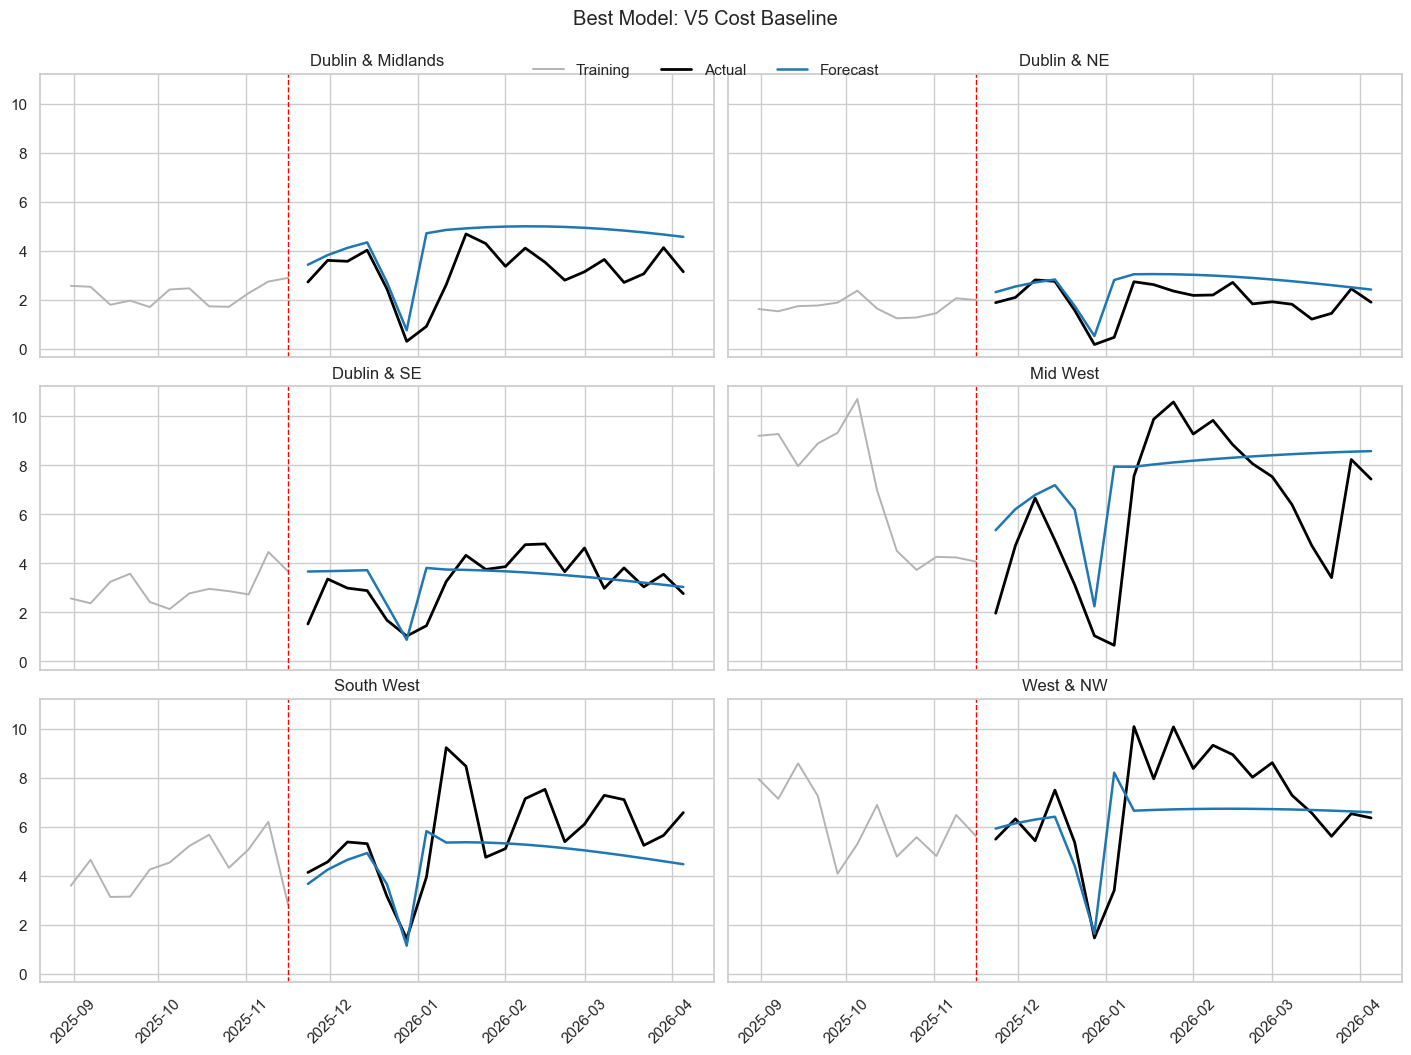

In [36]:
# ── Forecast vs actual for the best model ──

best = overall.iloc[0]
best_fc = fc[fc['model'] == best['model']]
recent_train = train_per10k.iloc[:, -12:]

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True, layout='constrained')
for region, ax in zip(regions, axes.flatten()):
    ax.plot(recent_train.columns, recent_train.loc[region], color='0.7', lw=1.4, label='Training')
    ax.plot(holdout_dates, holdout_per10k.loc[region, holdout_dates], color='black', lw=2, label='Actual')
    rf = best_fc.loc[best_fc['region'] == region].set_index('week_end')['forecast']
    ax.plot(holdout_dates, rf.reindex(holdout_dates), color='#1f77b4', lw=1.8, label='Forecast')
    ax.axvline(train_end, color='red', ls='--', lw=1)
    ax.set_title(SHORT_NAMES.get(region, region))
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False)
fig.suptitle(f'Best Model: {best["label"]}', y=1.04)
plt.show()